<a href="https://colab.research.google.com/github/trisskmasarahh/PCVK_Ganjil_2025/blob/main/kelompok8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**KELOMPOK 8**


In [ ]:
from google.colab import drive

drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os, math
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd




In [ ]:
BASE = '/content/drive/MyDrive/DATAKEL8'
IMAGE_PATHS = [os.path.join(BASE, f'face{i}.jpg') for i in [1,2,3]]

# A. Observasi & Eksperimen

# (1) Tampilkan histogram tiap citra + analisis (layout horizontal)

In [ ]:
def read_gray(path: str):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Tidak bisa membuka file: {path}")
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return bgr, gray

def stats(img: np.ndarray):
    img = img.astype(np.float32)
    return {
        "min": int(np.min(img)),
        "max": int(np.max(img)),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
    }

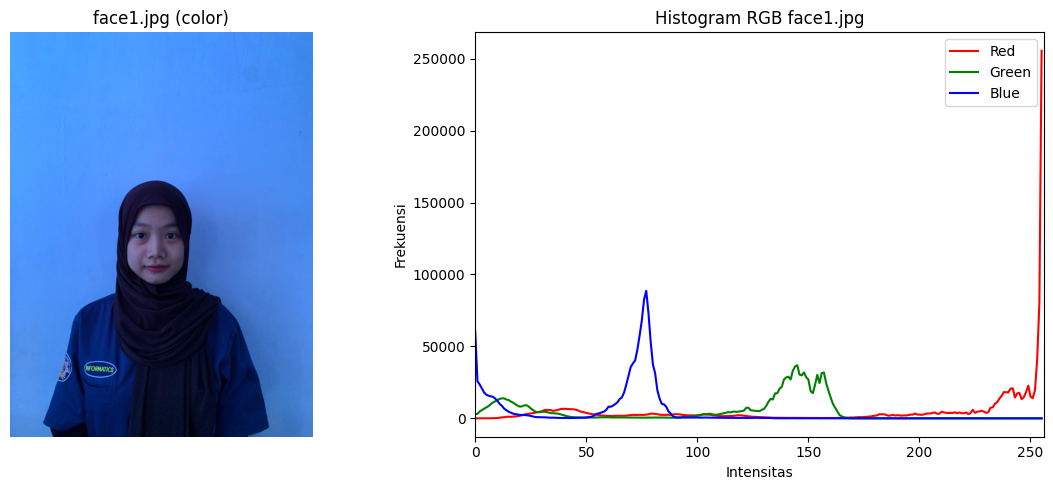

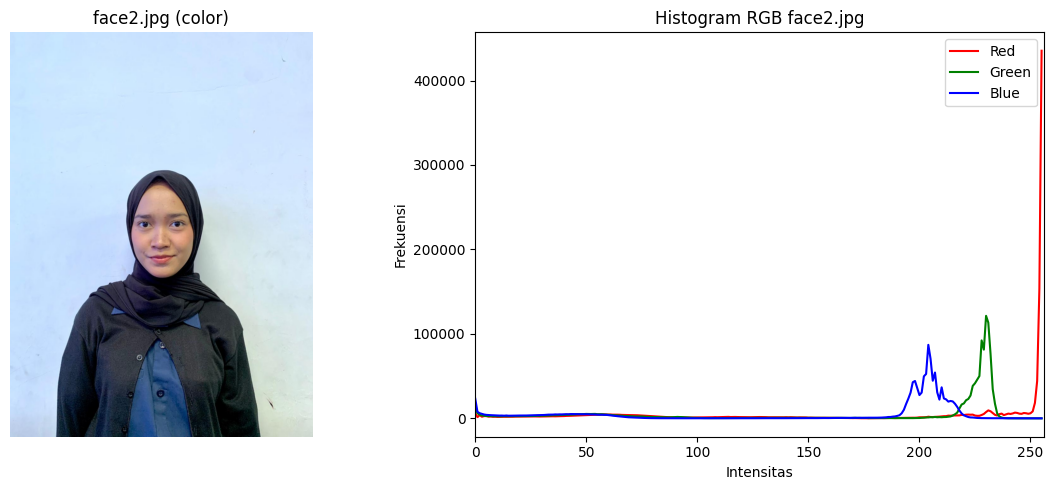

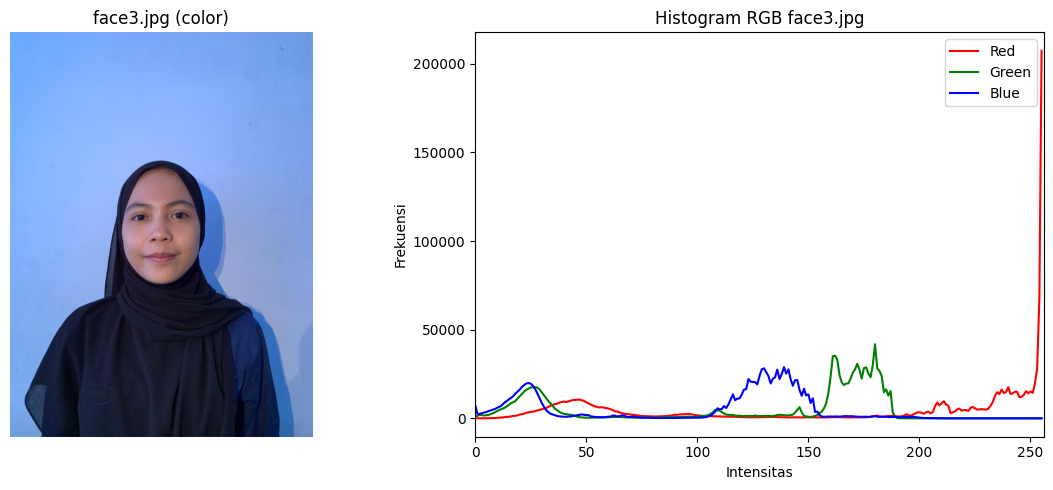

In [ ]:
# ========== A1. Histogram & Analisis Distribusi (RGB) ==========
for idx, p in enumerate(IMAGE_PATHS, start=1):
    color, gray = read_gray(p)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Gambar kiri → tampilkan warna asli
    img_rgb = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'face{idx}.jpg (color)')
    axes[0].axis('off')

    # Histogram kanan → tampilkan histogram untuk R, G, B
    colors = ('r', 'g', 'b')
    labels = ('Red', 'Green', 'Blue')
    for i, col in enumerate(colors):
        hist = cv2.calcHist([color], [i], None, [256], [0, 256])
        axes[1].plot(hist, color=col, label=labels[i])
    axes[1].set_xlim([0, 256])
    axes[1].set_title(f'Histogram RGB face{idx}.jpg')
    axes[1].set_xlabel('Intensitas')
    axes[1].set_ylabel('Frekuensi')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 2. Terapkan transformasi brightness dan contrast (linear/log brightness).

Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak natural.

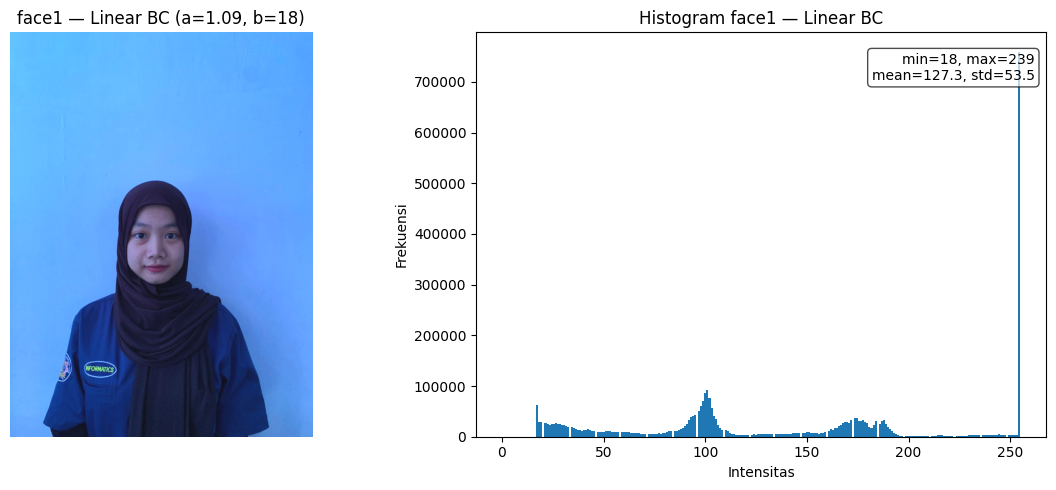

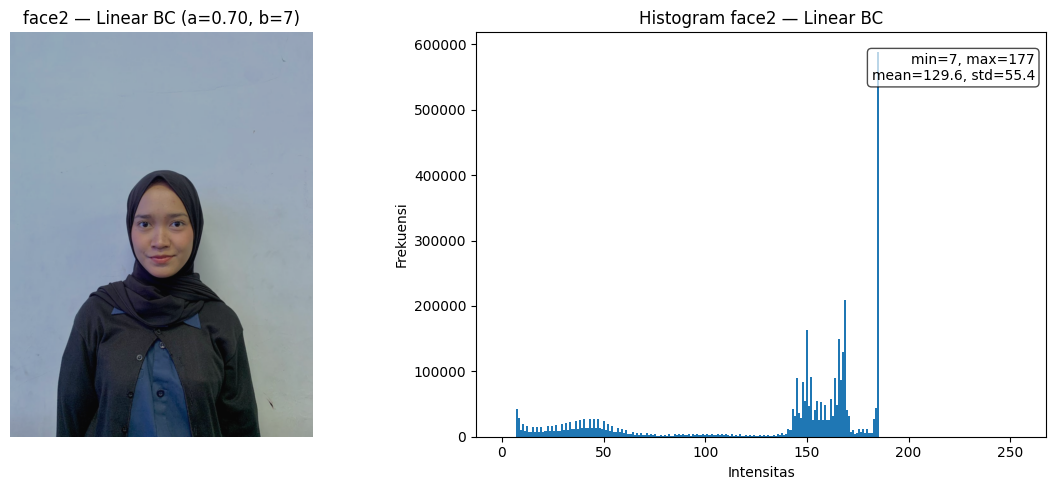

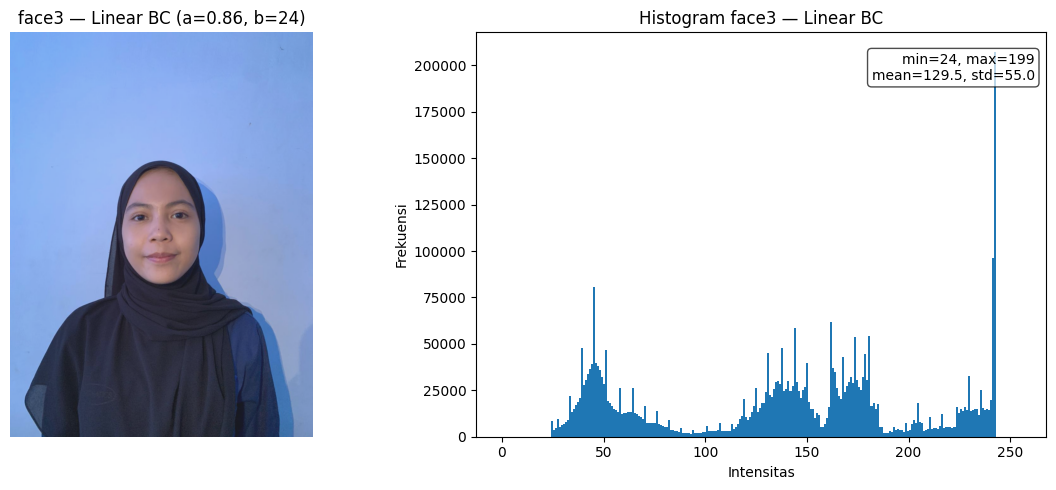

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def apply_linear_bc(img, a, b):
    out = a * img.astype(np.float32) + b
    return np.clip(out, 0, 255).astype(np.uint8)

def pick_ab_by_mean_std(gray, target_mean=130, target_std=55,
                        a_limits=(0.7, 1.5), b_limits=(-30, 30)):
    "Cari a (kontras) & b (brightness) agar mean≈target_mean dan std≈target_std."
    mean = float(gray.mean())
    std = float(gray.std())
    if std < 1:  # cegah div0 di gambar sangat flat
        std = 1.0
    a = target_std / std
    a = float(np.clip(a, a_limits[0], a_limits[1]))
    b = target_mean - a * mean
    b = float(np.clip(b, b_limits[0], b_limits[1]))
    return a, b

bc_linear_results = []
for idx, p in enumerate(IMAGE_PATHS, start=1):
    img = cv2.imread(p)                               # BGR
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # ke RGB utk plt

    # hitung a,b dari grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    a, b = pick_ab_by_mean_std(gray,
                               target_mean=130,
                               target_std=55)

    img_lin = apply_linear_bc(img_rgb, a=a, b=b)
    bc_linear_results.append((img_lin, a, b))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_lin)
    axes[0].set_title(f'face{idx} — Linear BC (a={a:.2f}, b={b:.0f})')
    axes[0].axis('off')

    gray_lin = cv2.cvtColor(img_lin, cv2.COLOR_RGB2GRAY)
    axes[1].hist(img_lin.ravel(), bins=256, range=(0,255))
    axes[1].set_title(f'Histogram face{idx} — Linear BC')
    axes[1].set_xlabel('Intensitas'); axes[1].set_ylabel('Frekuensi')
    axes[1].text(0.98, 0.95,
                 f"min={gray_lin.min()}, max={gray_lin.max()}\n"
                 f"mean={gray_lin.mean():.1f}, std={gray_lin.std():.1f}",
                 ha='right', va='top', transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout(); plt.show()

# 3. Histogram Equalization: sebelum–sesudah (masing-masing horizontal)

Bandingkan hasil visual dan histogram sebelum–sesudah.

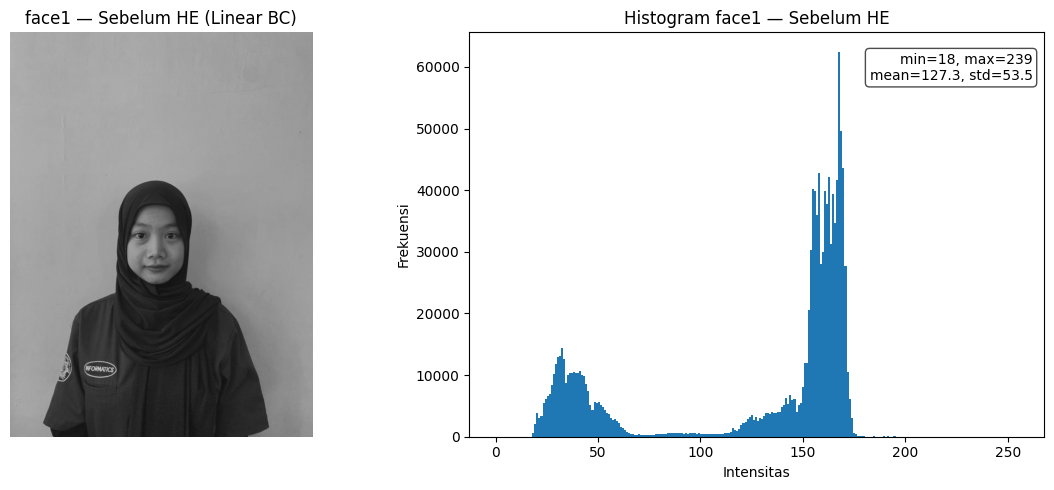

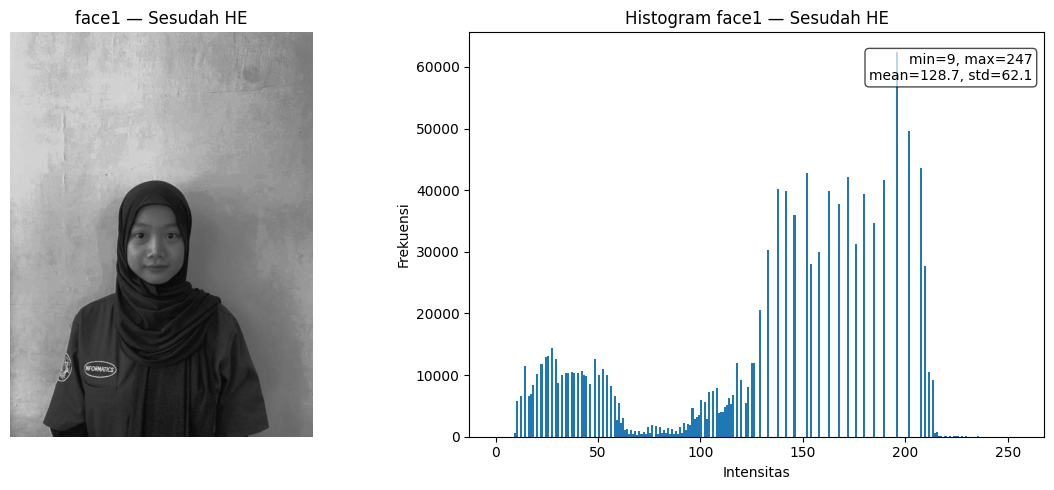

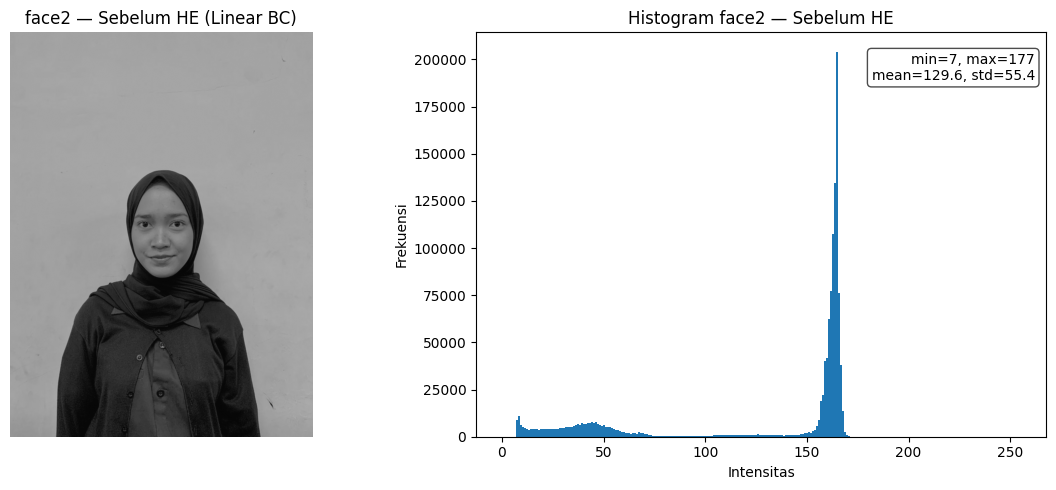

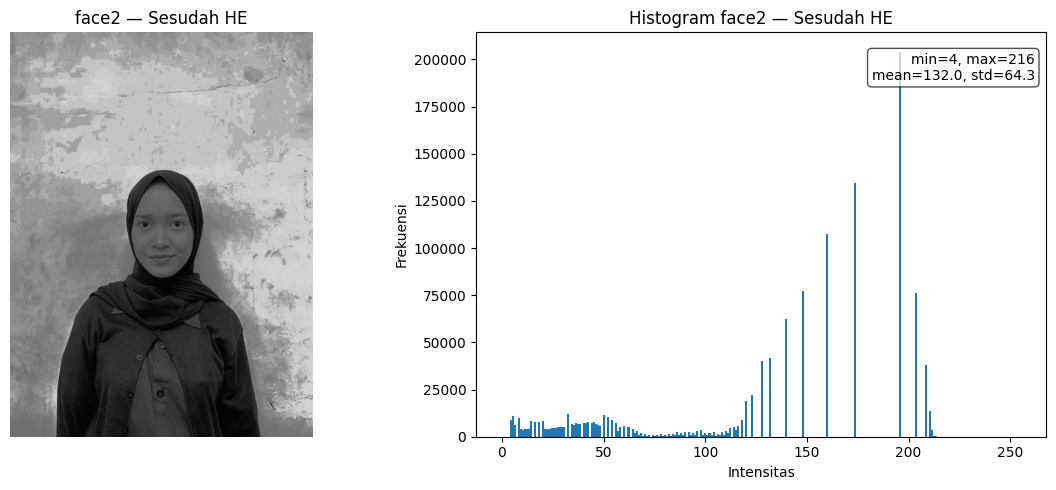

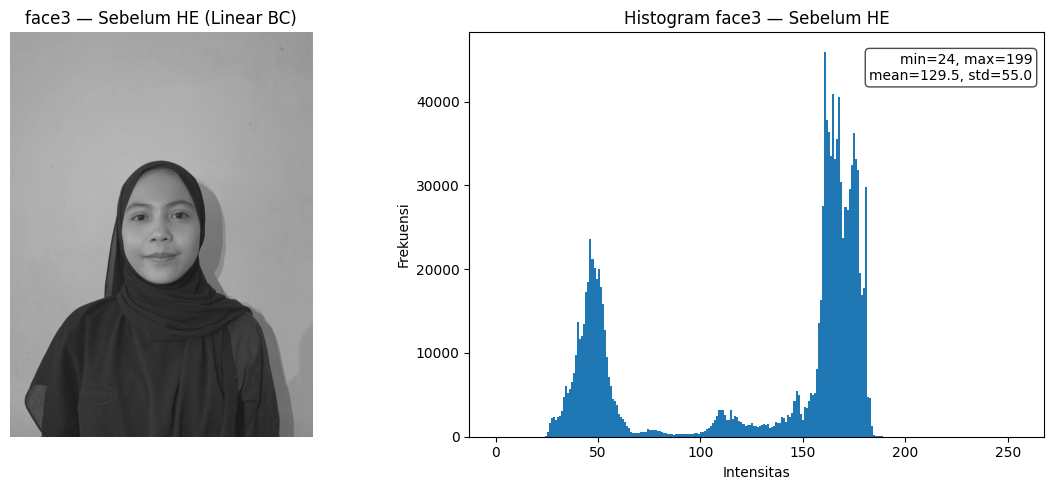

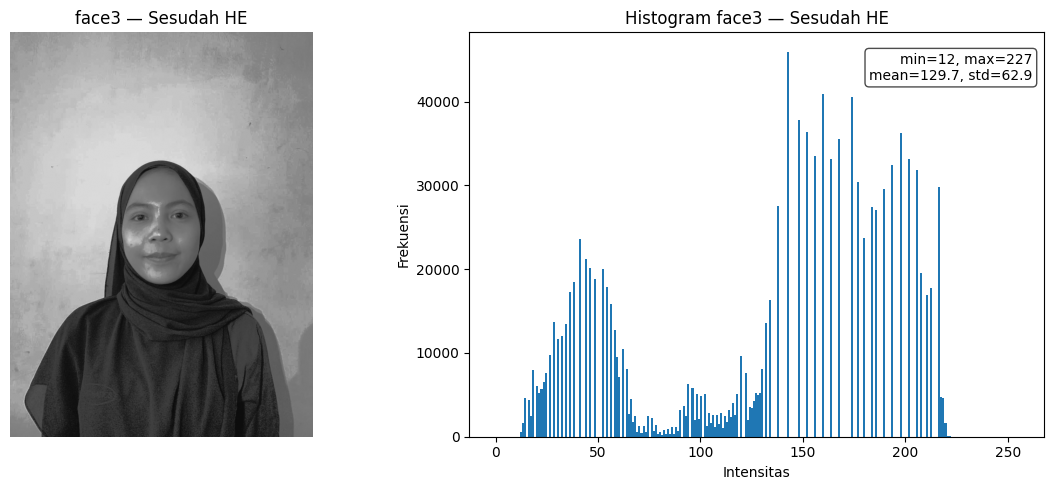

In [ ]:
def equalize(img_gray):
    img_gray_8u = cv2.convertScaleAbs(img_gray)
    he = cv2.equalizeHist(img_gray_8u)
    return cv2.addWeighted(img_gray_8u, 0.5, he, 0.5, 0)

he_results = []
for idx, (p, lin_pack) in enumerate(zip(IMAGE_PATHS, bc_linear_results), start=1):
    img_lin, a, b = lin_pack  # ambil gambar hasil Linear BC
    gray_lin = cv2.cvtColor(img_lin, cv2.COLOR_RGB2GRAY)  # ubah ke grayscale
    gray_he = equalize(gray_lin)
    he_results.append(gray_he)

    # Sebelum HE
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gray_lin, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'face{idx} — Sebelum HE (Linear BC)')
    axes[0].axis('off')

    s_lin = stats(gray_lin)
    axes[1].hist(gray_lin.ravel(), bins=256, range=(0,255))
    axes[1].set_title(f'Histogram face{idx} — Sebelum HE')
    axes[1].set_xlabel('Intensitas'); axes[1].set_ylabel('Frekuensi')
    axes[1].text(0.98, 0.95,
                 f"min={s_lin['min']}, max={s_lin['max']}\nmean={s_lin['mean']:.1f}, std={s_lin['std']:.1f}",
                 ha='right', va='top', transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout(); plt.show()

    # Sesudah HE
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gray_he, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'face{idx} — Sesudah HE')
    axes[0].axis('off')

    s_he = stats(gray_he)
    axes[1].hist(gray_he.ravel(), bins=256, range=(0,255))
    axes[1].set_title(f'Histogram face{idx} — Sesudah HE')
    axes[1].set_xlabel('Intensitas'); axes[1].set_ylabel('Frekuensi')
    axes[1].text(0.98, 0.95,
                 f"min={s_he['min']}, max={s_he['max']}\nmean={s_he['mean']:.1f}, std={s_he['std']:.1f}",
                 ha='right', va='top', transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout(); plt.show()

# 4. Filter Spasial: Low-pass (kulit) & High-pass/Laplacian (tepi) — horizontal

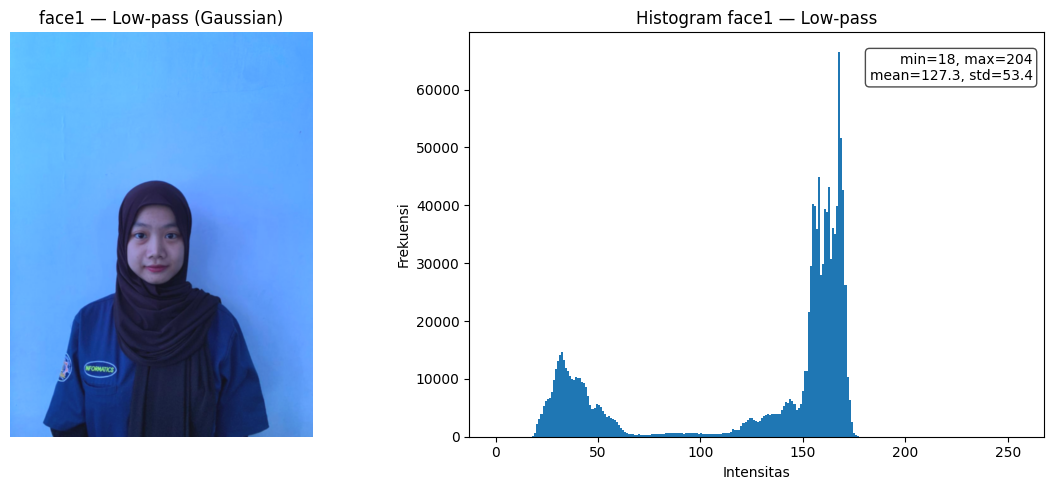

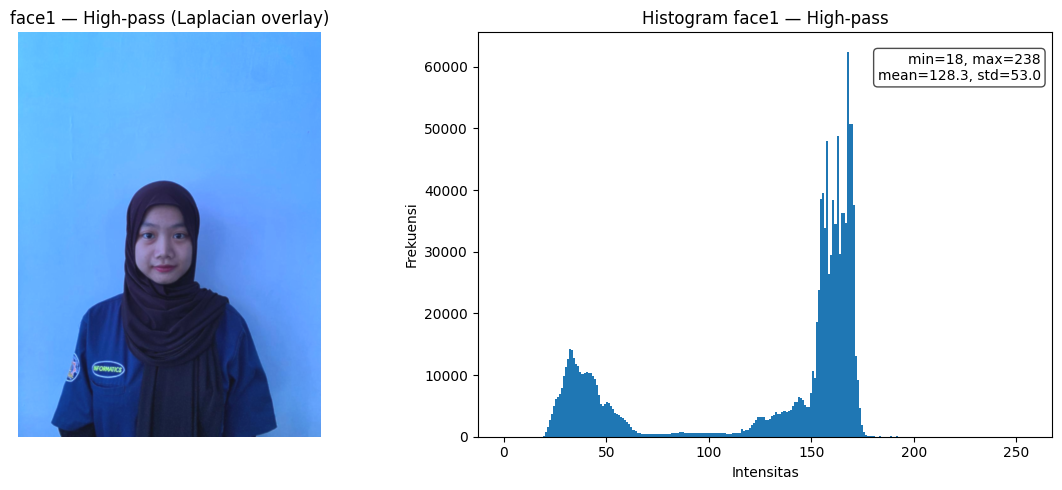

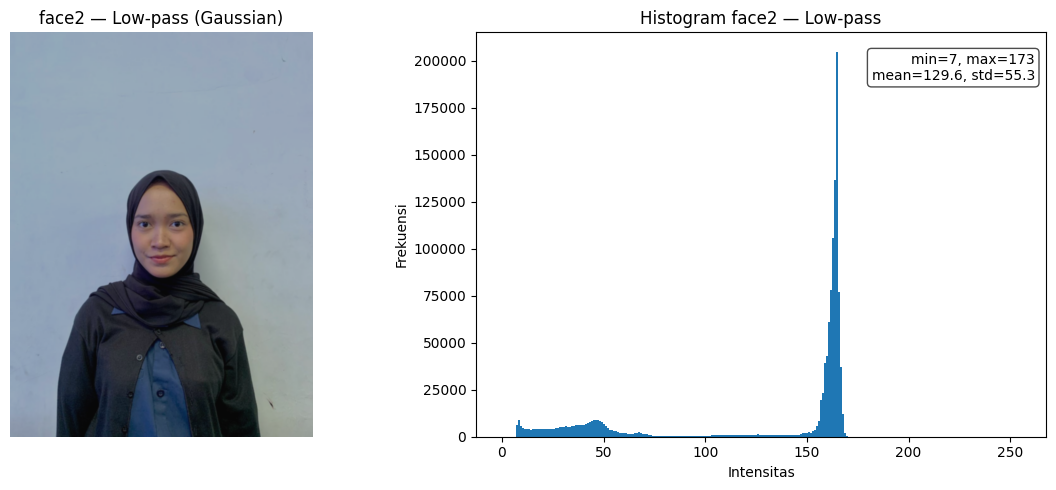

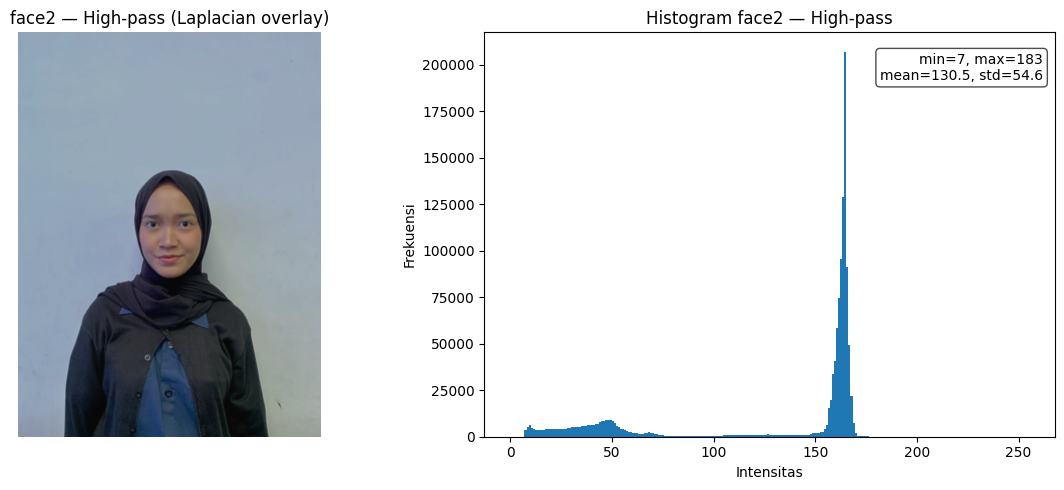

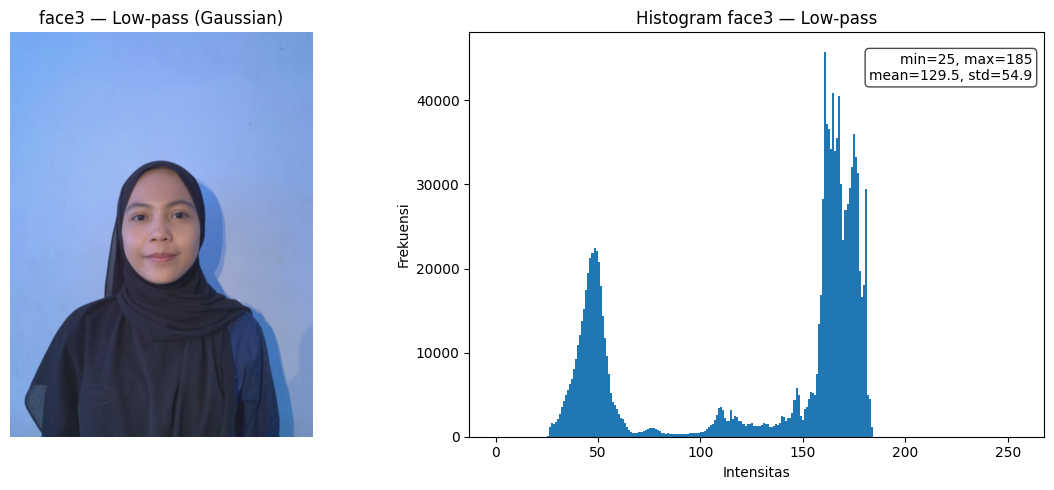

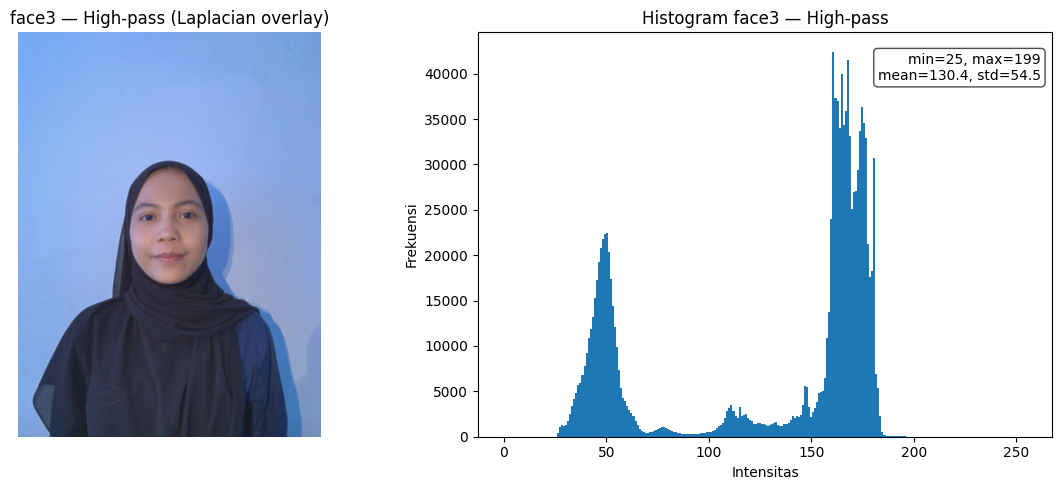

In [ ]:
# ========== A4. Low-pass & High-pass (Laplacian) ==========
# --- low-pass di RGB (Gaussian) ---
def lowpass_gaussian(img_rgb, ksize=5, sigma=1.2):
    ksize = int(ksize) | 1
    return cv2.GaussianBlur(img_rgb, (ksize, ksize), sigma)

# --- high-pass/Laplacian dari luminance, overlay ke RGB ---
def highpass_laplacian(img_rgb, alpha=0.30, ksize=3):
    # hitung edge dari luminance (grayscale)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_16S, ksize=ksize)
    lap  = cv2.convertScaleAbs(lap)  # uint8 edge map

    # overlay ke RGB
    sharpened = cv2.addWeighted(img_rgb, 1.0, cv2.cvtColor(lap, cv2.COLOR_GRAY2RGB), alpha, 0)
    return sharpened, lap

lp_results, hp_results = [], []
for idx, (p, lin_pack) in enumerate(zip(IMAGE_PATHS, bc_linear_results), start=1):
    # lin_pack berisi (img_lin_RGB, a, b) dari langkah BC
    img_lin, _, _ = lin_pack

    # 1) Low-pass smoothing di RGB untuk kulit
    lp_rgb = lowpass_gaussian(img_lin, ksize=5, sigma=1.2)

    # 2) High-pass/Laplacian dari luminance, overlay ke RGB
    hp_rgb, lap = highpass_laplacian(lp_rgb, alpha=0.30, ksize=3)

    lp_results.append(lp_rgb)
    hp_results.append(hp_rgb)

    # ---------- VISUAL & HISTOGRAM: LOW-PASS ----------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(lp_rgb)
    axes[0].set_title(f'face{idx} — Low-pass (Gaussian)')
    axes[0].axis('off')

    gray_lp = cv2.cvtColor(lp_rgb, cv2.COLOR_RGB2GRAY)
    s_lp = stats(gray_lp)
    axes[1].hist(gray_lp.ravel(), bins=256, range=(0,255))
    axes[1].set_title(f'Histogram face{idx} — Low-pass')
    axes[1].set_xlabel('Intensitas'); axes[1].set_ylabel('Frekuensi')
    axes[1].text(0.98, 0.95, f"min={s_lp['min']}, max={s_lp['max']}\nmean={s_lp['mean']:.1f}, std={s_lp['std']:.1f}",
                 ha='right', va='top', transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout(); plt.show()

    # ---------- VISUAL & HISTOGRAM: HIGH-PASS / LAPLACIAN ----------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(hp_rgb)
    axes[0].set_title(f'face{idx} — High-pass (Laplacian overlay)')
    axes[0].axis('off')

    gray_hp = cv2.cvtColor(hp_rgb, cv2.COLOR_RGB2GRAY)
    s_hp = stats(gray_hp)
    axes[1].hist(gray_hp.ravel(), bins=256, range=(0,255))
    axes[1].set_title(f'Histogram face{idx} — High-pass')
    axes[1].set_xlabel('Intensitas'); axes[1].set_ylabel('Frekuensi')
    axes[1].text(0.98, 0.95, f"min={s_hp['min']}, max={s_hp['max']}\nmean={s_hp['mean']:.1f}, std={s_hp['std']:.1f}",
                 ha='right', va='top', transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout(); plt.show()

# 5. Floyd–Steinberg Dithering 4–6 bit + histogram (horizontal) + statistik

In [ ]:
# --- Floyd–Steinberg Dithering (grayscale), target n_bits (4–6) ---
def _quant_step(n_bits: int):
    levels = 2 ** n_bits            # 4 bit -> 16 level, 5 bit -> 32, 6 bit -> 64
    step = 255.0 / (levels - 1)     # jarak antar level
    return levels, step

def floyd_steinberg(gray_u8, n_bits: int = 5):
    if gray_u8.ndim != 2:
        raise ValueError("Input harus grayscale 2D.")
    if gray_u8.dtype != np.uint8:
        gray_u8 = cv2.convertScaleAbs(gray_u8)

    _, step = _quant_step(n_bits)
    buf = gray_u8.astype(np.float32).copy()
    h, w = buf.shape

    for y in range(h):
        for x in range(w):
            old = buf[y, x]
            new = round(old / step) * step
            err = old - new
            buf[y, x] = new

            # Sebarkan error (cek batas)
            if x + 1 < w:
                buf[y, x+1] += err * (7/16)
            if y + 1 < h:
                if x - 1 >= 0:
                    buf[y+1, x-1] += err * (3/16)
                buf[y+1, x] += err * (5/16)
                if x + 1 < w:
                    buf[y+1, x+1] += err * (1/16)

    return np.clip(buf, 0, 255).astype(np.uint8)

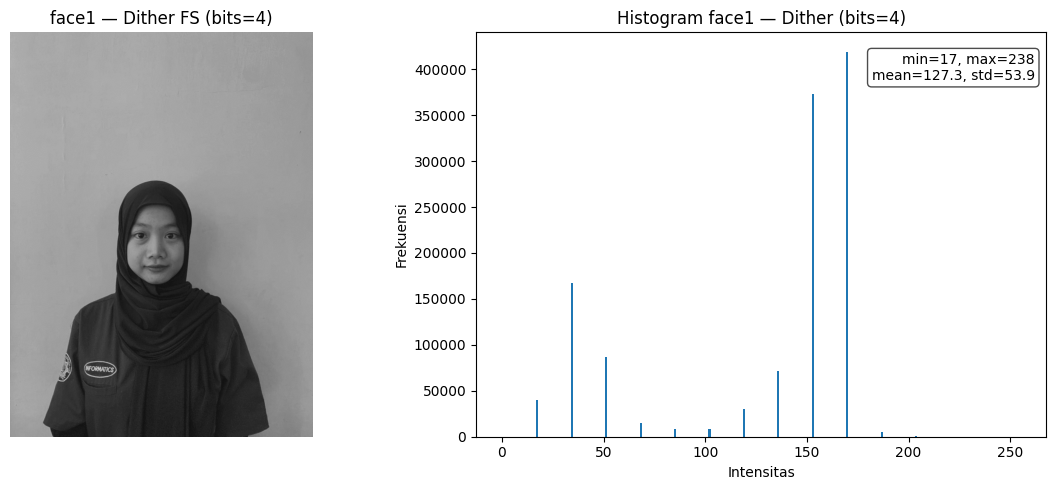

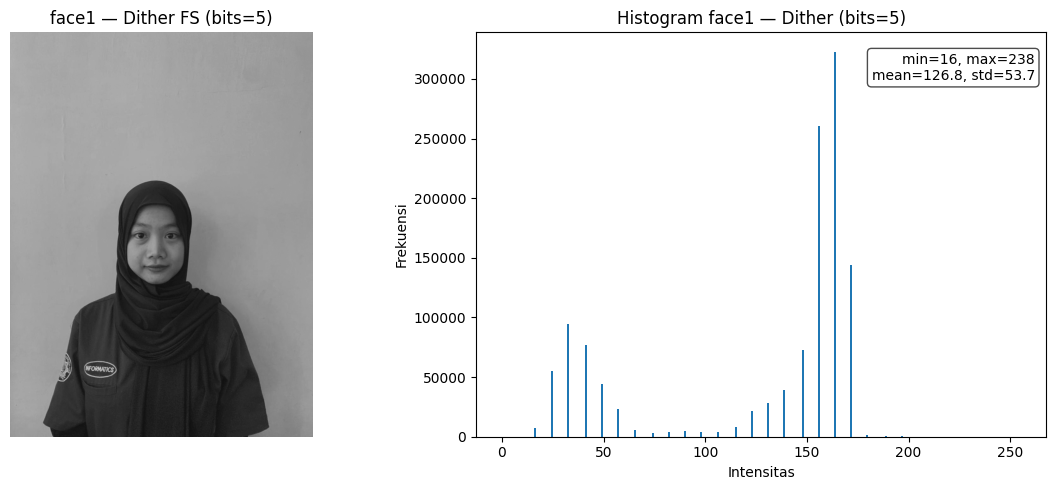

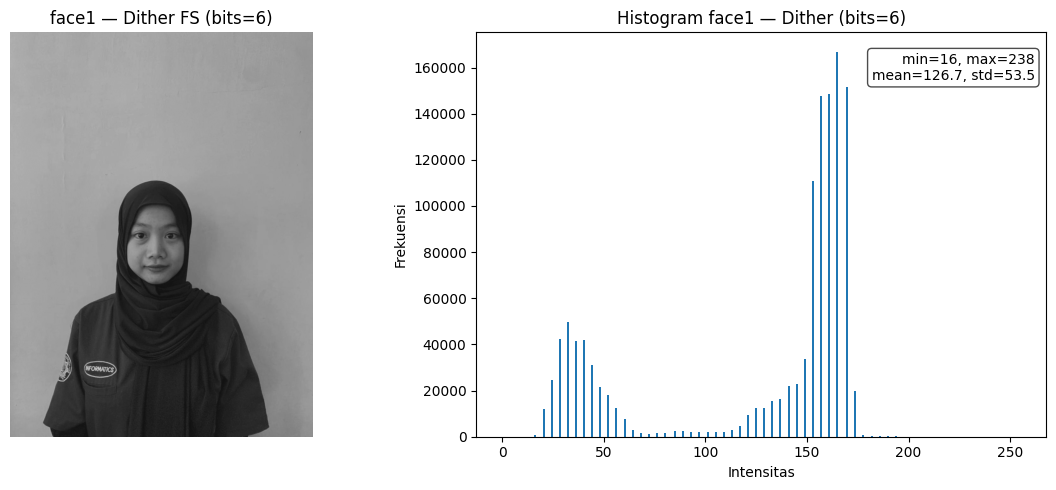

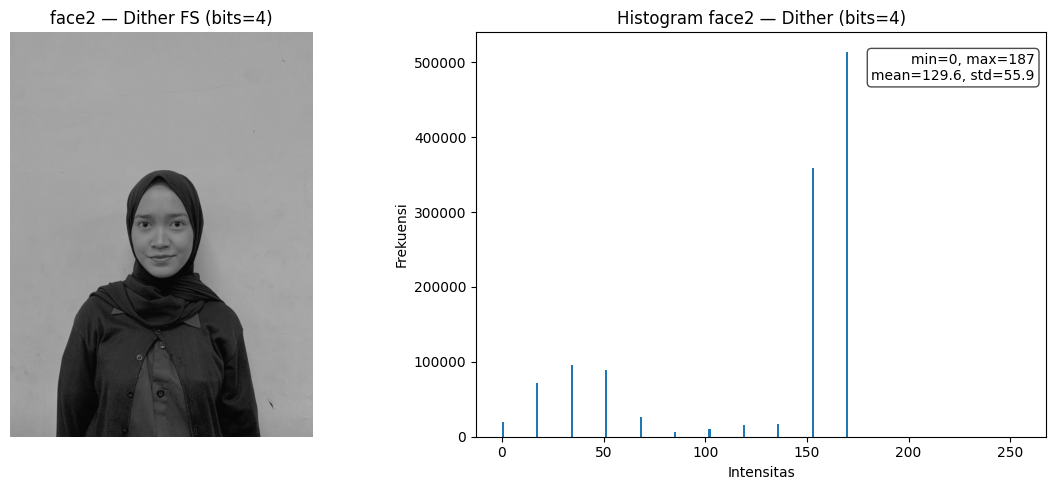

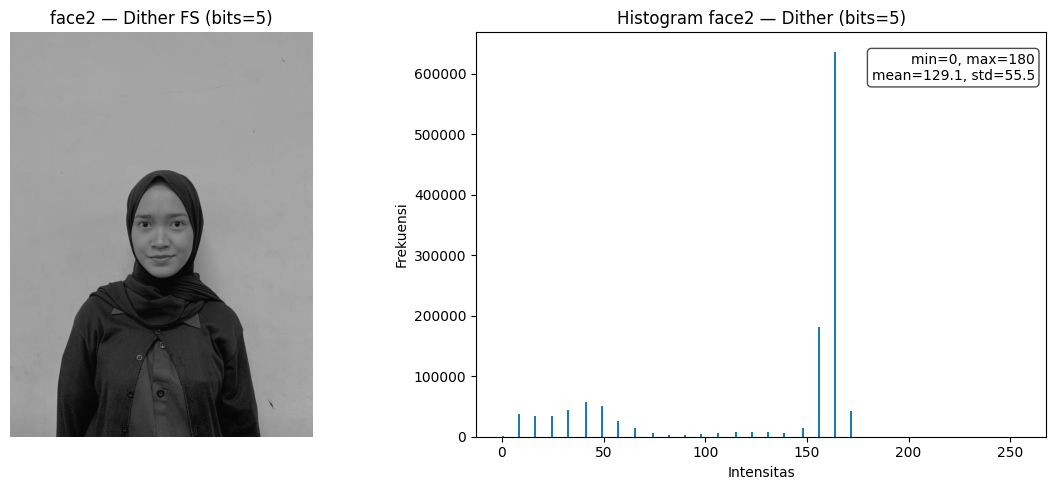

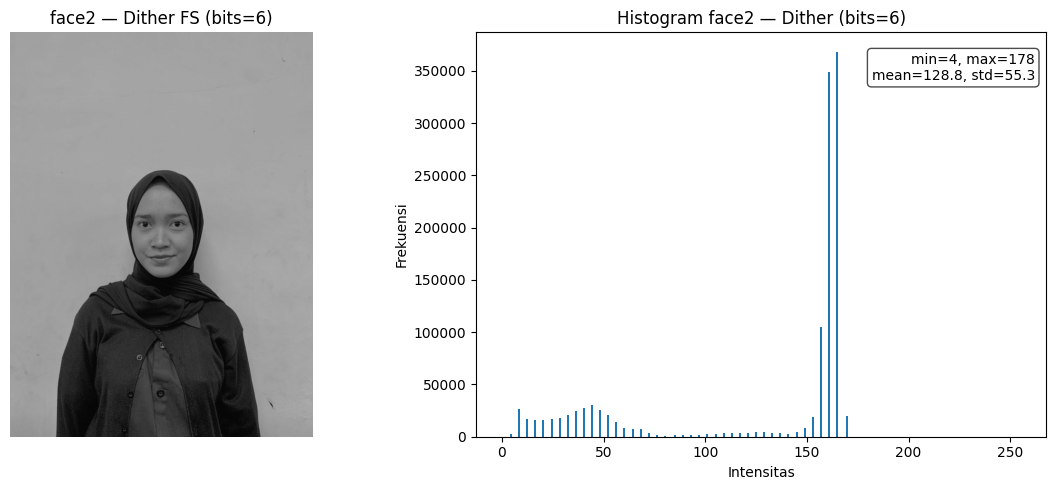

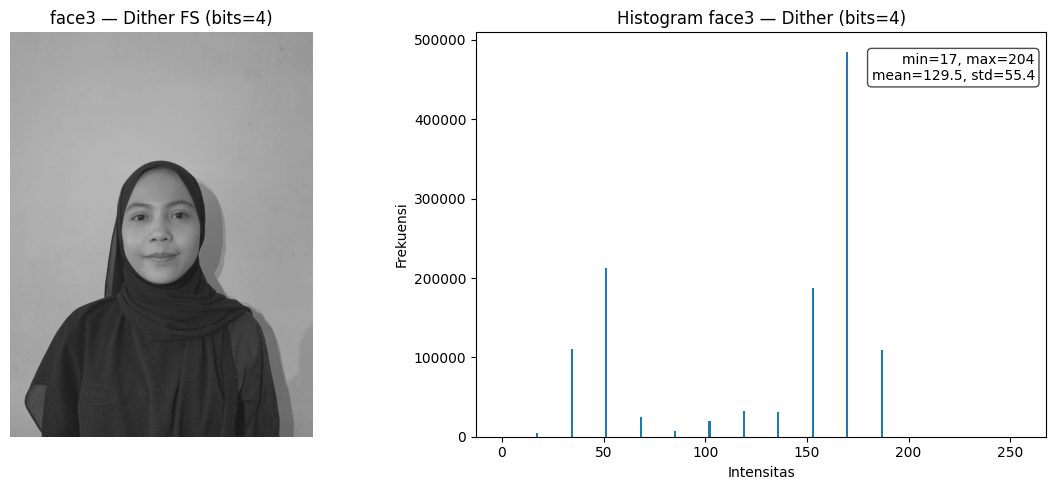

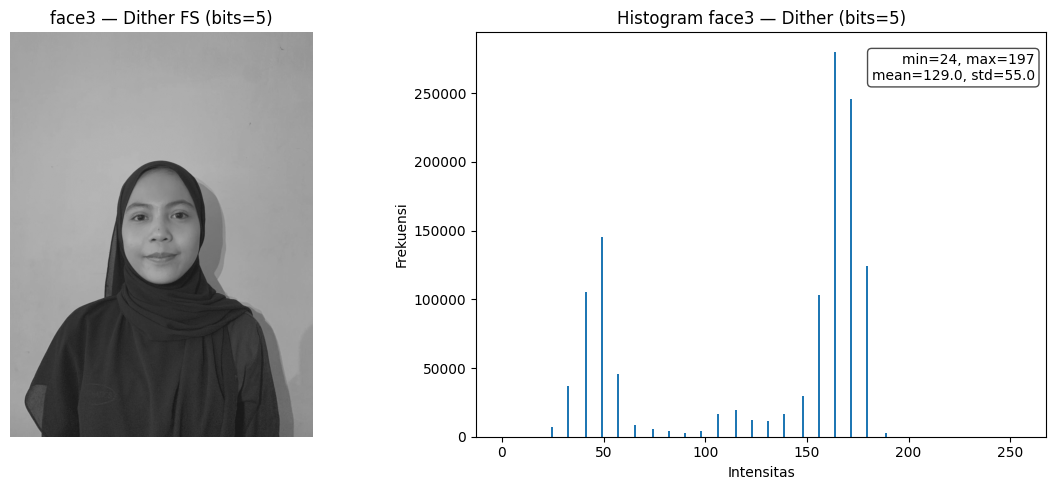

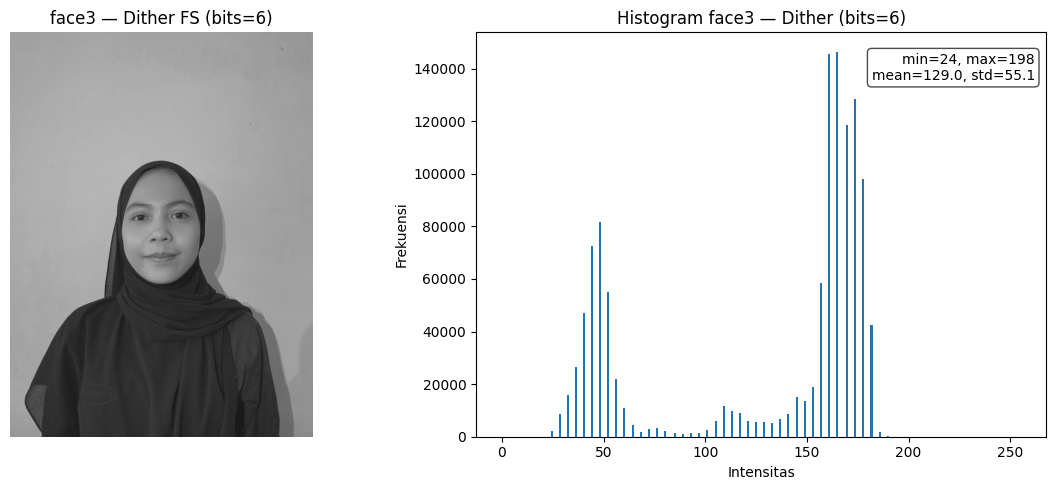

In [ ]:
# ========== A5. Floyd–Steinberg Dithering (4–6 bit) ==========
for idx, (p, lin_pack) in enumerate(zip(IMAGE_PATHS, bc_linear_results), start=1):
    img_lin, _, _ = lin_pack
    gray_lin = cv2.cvtColor(img_lin, cv2.COLOR_RGB2GRAY)

    for bits in [4, 5, 6]:
        dimg = floyd_steinberg(gray_lin, n_bits=bits)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(dimg, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title(f'face{idx} — Dither FS (bits={bits})')
        axes[0].axis('off')

        s = stats(dimg)
        axes[1].hist(dimg.ravel(), bins=256, range=(0,255))
        axes[1].set_title(f'Histogram face{idx} — Dither (bits={bits})')
        axes[1].set_xlabel('Intensitas'); axes[1].set_ylabel('Frekuensi')
        axes[1].text(0.98, 0.95,
                     f"min={s['min']}, max={s['max']}\nmean={s['mean']:.1f}, std={s['std']:.1f}",
                     ha='right', va='top', transform=axes[1].transAxes,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        plt.tight_layout(); plt.show()



> Analisis per wajah

1. Wajah Gelap
    
    Citra ini memiliki tantangan terbesar karena sebagian besar informasinya terkumpul di intensitas rendah.

    * 6-bit (64 level keabuan): Pada level ini, dithering masih mampu mempertahankan sebagian besar fitur utama wajah. Ekspresi wajah masih dapat dikenali, meskipun tekstur kulit mulai terlihat lebih kasar karena pola dithering. Detail pada area bayangan seperti di sekitar mata dan hidung mulai sedikit menyatu.

    * 5-bit (32 level keabuan): Penurunan detail menjadi lebih jelas. Pola dithering menjadi lebih kasar dan terlihat. Ekspresi wajah masih bisa ditangkap, tetapi nuansa halus (misalnya, sedikit tarikan di sudut bibir) hampir hilang. Terjadi posterization (efek seperti poster) yang nyata di area pipi dan dahi.

    * 4-bit (16 level keabuan): Pada titik ini, detail wajah mengalami degradasi parah. Sebagian besar area gelap menyatu menjadi satu warna, menyebabkan fitur seperti mata dan bibir kehilangan kontur jelasnya. Ekspresi wajah menjadi sangat kabur dan sulit diinterpretasikan. Pola dithering sangat dominan dan mengganggu.



---

2. Wajah Terang

   Citra ini memiliki kontras yang baik, menjadi basis perbandingan yang bagus.

   * 6-bit (64 level keabuan): Hasilnya masih sangat baik dan mirip dengan citra hasil filter. Pola dithering hampir tidak terlihat mengganggu dan detail ekspresi wajah (mata, bibir, alis) terjaga dengan sangat baik.

    * 5-bit (32 level keabuan): Detail mulai berkurang, terutama pada area yang terang dan halus seperti dahi dan pipi. Pola dithering mulai terlihat, memberikan tekstur "berpasir". Namun, ekspresi wajah secara keseluruhan masih sangat jelas dan tidak terganggu.

    * 4-bit (16 level keabuan): Terjadi banding (garis-garis tegas antar gradasi warna) pada area transisi cahaya seperti dari pipi ke rahang. Detail halus seperti kilau di mata mungkin hilang. Meskipun ekspresi utama masih terlihat, citra tampak tidak natural dan kasar.

  

---

3. Wajah Berbayang

    Citra ini memiliki rentang dinamis yang tinggi, dengan area sangat terang dan sangat gelap.

    * 6-bit (64 level keabuan): Dithering bekerja cukup baik. Ia berhasil merepresentasikan gradasi di sisi wajah yang terang maupun yang gelap tanpa kehilangan informasi ekspresi secara signifikan. Pola dithering sedikit lebih terlihat di area bayangan.

    * 5-bit (32 level keabuan): Area di dalam bayangan mulai kehilangan banyak detail dan menyatu. Di sisi lain, area yang terang menunjukkan pola dithering yang lebih jelas. Perbedaan kontras antara dua sisi wajah menjadi lebih kasar. Ekspresi masih bisa dibaca, tetapi terkesan "terbelah".

    * 4-bit (16 level keabuan): Detail di area bayangan hampir sepenuhnya hilang, menjadi blok warna gelap. Transisi antara terang dan gelap menjadi garis yang sangat tajam dan tidak natural. Ekspresi wajah menjadi ambigu karena detail penting di separuh wajah telah hilang.

  

---

| Kondisi Citra & Bit-Depth | Efek pada Detail Mikro (Tekstur Kulit, Kerutan) | Efek pada Kontur Makro (Bentuk Rahang, Hidung) | Artefak Visual yang Diperkenalkan | Dampak pada Keterbacaan Ekspresi Wajah |
|:---|:---|:---|:---|:---|
| **Wajah Gelap, 4-bit** | Detail hilang, digantikan tekstur kasar. | Kontur dapat muncul secara artifisial namun terlihat bergerigi. | Pola titik-titik (*stippling*) yang sangat jelas dan kasar. | Berpotensi terdistorsi atau hilang dalam pola *dither*. |
| **Wajah Gelap, 6-bit** | Sebagian detail halus terjaga, tekstur kulit sedikit kasar. | Kontur lebih jelas dan lebih halus dibandingkan 4-bit. | Pola titik-titik yang lebih halus dan kurang mengganggu. | Umumnya masih dapat dibaca dengan baik. |
| **Wajah Terang, 4-bit** | Detail di area sorotan hilang, tekstur "berpasir". | Kontur di area terang menjadi kabur. | *Banding* berkurang, namun muncul tekstur kasar. | Ekspresi yang melibatkan area sorotan (misal, kerutan dahi) bisa hilang. |
| **Wajah Terang, 6-bit** | Detail di area terang lebih terjaga, tekstur lebih halus. | Kontur tetap terjaga dengan baik. | Pola *dither* halus, hampir tidak terlihat. | Ekspresi wajah sebagian besar tidak terpengaruh. |
| **Wajah Berbayang, 4-bit** | Tekstur asli di sepanjang garis bayangan hilang. | Transisi bayangan menjadi kasar namun terdefinisi. | Pola *dither* yang jelas di sepanjang gradien kontras. | Ekspresi bisa menjadi lebih dramatis namun tidak natural. |
| **Wajah Berbayang, 6-bit** | Tekstur kulit di garis bayangan lebih terjaga. | Transisi bayangan lebih halus dan natural. | Pola *dither* halus yang membantu gradasi. | Ekspresi wajah tetap terjaga dengan fidelitas tinggi. |

# B. Analisis

1. Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah gelap?

    Pada citra wajah gelap, histogram awalnya sangat condong ke kiri, menunjukkan bahwa mayoritas piksel memiliki intensitas yang sangat rendah (mendekati hitam).

    * Meningkatkan Brightness (beta): Operasi ini menggeser seluruh histogram ke kanan. Secara visual, semua piksel menjadi lebih terang secara seragam. Distribusi piksel yang tadinya menumpuk di nilai 0-50, kini bergeser mungkin ke 30-80.

    * Meningkatkan Contrast (alpha): Operasi ini merentangkan (stretching) histogram. Piksel yang gelap dibuat sedikit lebih gelap, dan piksel yang terang dibuat jauh lebih terang. Ini membuat rentang histogram menjadi lebih lebar. Kombinasi keduanya pada wajah gelap akan menggeser dan merentangkan histogram, sehingga distribusi intensitas yang tadinya sempit di sebelah kiri menjadi lebih lebar dan bergeser ke tengah. Ini menandakan citra memiliki rentang kecerahan yang lebih seimbang.
  


---

2. Apakah histogram equalization selalu memperbaiki detail wajah? Jelaskan.

    Tidak selalu. Histogram Equalization (HE) tidak selalu memperbaiki detail.

    * Contoh Keberhasilan (Wajah Gelap & Berbayang): Pada wajah_gelap dan wajah_berbayang, HE sangat efektif. Ia meratakan kontras yang tadinya buruk, sehingga detail-detail di area gelap yang sebelumnya tidak terlihat (seperti bentuk mata atau garis bibir) menjadi jauh lebih jelas.

    * Contoh Kegagalan (Wajah Terang): Pada wajah_terang yang kontrasnya sudah baik, HE justru dapat merusak citra. HE akan "memaksa" distribusi piksel menjadi seragam, yang menyebabkan kontras menjadi berlebihan (terlalu tajam) dan tidak natural. Hal ini juga dapat memperkuat noise yang ada pada citra, yang sebelumnya tidak terlalu terlihat. Pada hasil Anda, kulit pada wajah_terang setelah HE mungkin terlihat lebih kasar.

  

---

3. Bandingkan hasil low-pass dan high-pass filter pada area wajah, bagian mana yang paling terpengaruh?

    * Low-Pass Filter (Filter Penghalus): Filter ini paling memengaruhi area dengan tekstur halus dan detail frekuensi tinggi, seperti pori-pori kulit, kerutan halus, dan noise acak. Setelah aplikasi low-pass filter, kulit wajah terlihat lebih halus dan mulus karena detail-detail kecil ini dihilangkan (diburamkan).

    * High-Pass Filter (Filter Penajam): Filter ini paling memengaruhi area dengan tepi (edge) yang tegas dan perubahan intensitas yang drastis. Bagian yang paling terpengaruh adalah garis mata, alis, garis bibir, lubang hidung, dan garis rahang. Setelah aplikasi high-pass filter, area-area ini menjadi lebih tajam, jelas, dan kontrasnya meningkat.

  

---
4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?

    Dithering adalah pedang bermata dua untuk ekspresi wajah.

    * Mempertegas: Dengan mengurangi jumlah warna, dithering memaksa fitur-fitur wajah direpresentasikan dengan cara yang lebih sederhana dan kontras. Ini kadang bisa bekerja seperti karikatur atau sketsa, di mana garis-garis utama sebuah ekspresi (seperti lengkungan senyum atau kerutan dahi) menjadi lebih menonjol dan tegas karena tidak ada gradasi halus yang membingungkan.

    * Mengaburkan: Ekspresi wajah manusia seringkali bergantung pada nuansa dan gradasi yang sangat halus, misalnya sedikit tarikan di sudut bibir atau kilau di mata. Proses kuantisasi warna pada dithering dapat menghilangkan gradasi halus ini dengan menggabungkan beberapa tingkat keabuan menjadi satu. Akibatnya, nuansa ekspresi tersebut hilang, membuat wajah tampak datar atau ekspresinya menjadi ambigu dan kabur.



---

5. Berdasarkan hasil percobaan, kombinasi teknik mana yang paling efektif?

    Berdasarkan hasil eksperimen pada ketiga citra, urutan kombinasi yang paling efektif untuk meningkatkan "readability" fitur wajah sebelum tahap deteksi (terutama untuk kasus citra yang kurang ideal) adalah:

    * Brightness & Contrast Adjustment: Ini adalah langkah pertama yang paling krusial untuk menormalkan pencahayaan secara global, terutama pada citra yang terlalu gelap atau kusam.

    * Histogram Equalization: Setelah pencahayaan dinormalkan, HE sangat efektif untuk memaksimalkan kontras lokal dan global, membuat setiap fitur wajah (mata, hidung, mulut) menonjol dari latar sekitarnya.

    * High-Pass Filter (Sharpening): Sebagai langkah terakhir, penajaman menggunakan filter high-pass (seperti Laplacian) sangat berguna untuk mempertegas tepi-tepi fitur kunci yang akan digunakan oleh model face recognition.

Kombinasi ini (BC → HE → HP Filter) secara konsisten memberikan hasil di mana fitur-fitur wajah paling jelas dan siap untuk dianalisis oleh mesin, terutama pada wajah_gelap dan wajah_berbayang. Dithering tidak direkomendasikan karena merupakan proses yang menghilangkan informasi.


# C. Implementasi (Phyton-OpenCv)

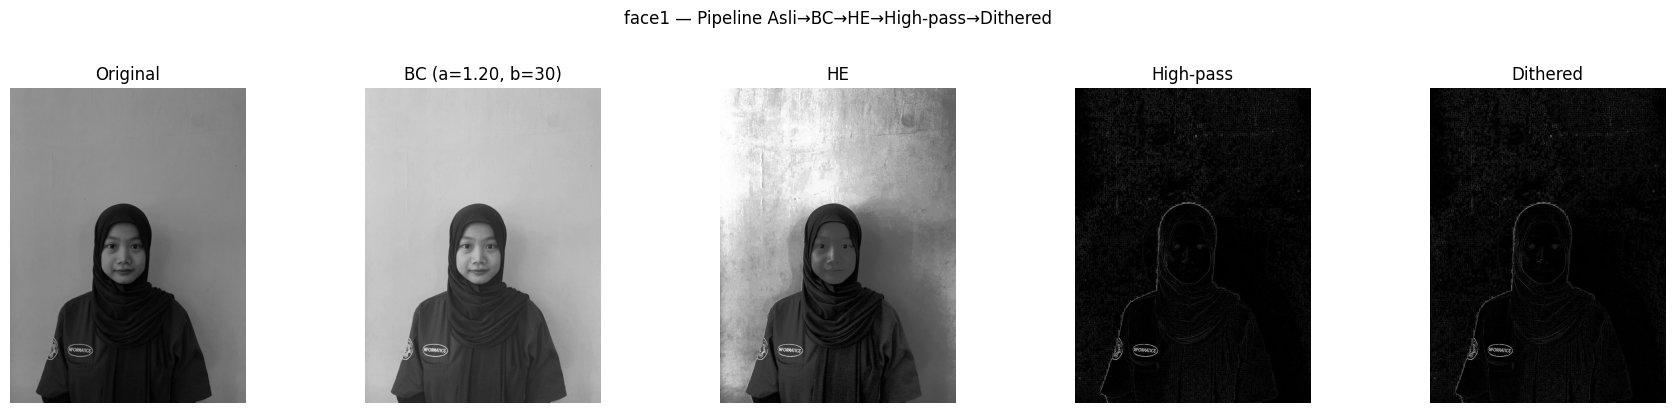

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DATAKEL8/face1.jpg', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Brightness & Contrast
b, a = 30, 1.2
img_bc = cv2.convertScaleAbs(gray, alpha=a, beta=b)

# Histogram Equalization
img_he = cv2.equalizeHist(img_bc)

# Spatial Filtering
kernel_hp = np.array([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1]], dtype=np.float32)
img_hp = cv2.filter2D(img_he, -1, kernel_hp)

# Dithering
img_dith = floyd_steinberg(img_hp, n_bits=5)

# Panel 5 tahap: Original → BC → HE → High-pass → Dithered
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(gray,    cmap='gray', vmin=0, vmax=255); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_bc,  cmap='gray', vmin=0, vmax=255); axes[1].set_title(f'BC (a={a:.2f}, b={b:.0f})'); axes[1].axis('off')
axes[2].imshow(img_he,  cmap='gray', vmin=0, vmax=255); axes[2].set_title('HE'); axes[2].axis('off')
axes[3].imshow(img_hp,  cmap='gray', vmin=0, vmax=255); axes[3].set_title('High-pass'); axes[3].axis('off')
axes[4].imshow(img_dith,cmap='gray', vmin=0, vmax=255); axes[4].set_title('Dithered'); axes[4].axis('off')
fig.suptitle('face1 — Pipeline Asli→BC→HE→High-pass→Dithered', y=1.02)
plt.tight_layout(); plt.show()

# D. Analisis Akhir & Kesimpulan

Referensi (warna asli): /content/drive/MyDrive/DATAKEL8/face2.jpg
     Skenario  PSNR (dB)
0    Blur 3x3     39.798
1    Blur 5x5     35.312
2  Detail 3x3     50.223
3  Detail 5x5     40.077


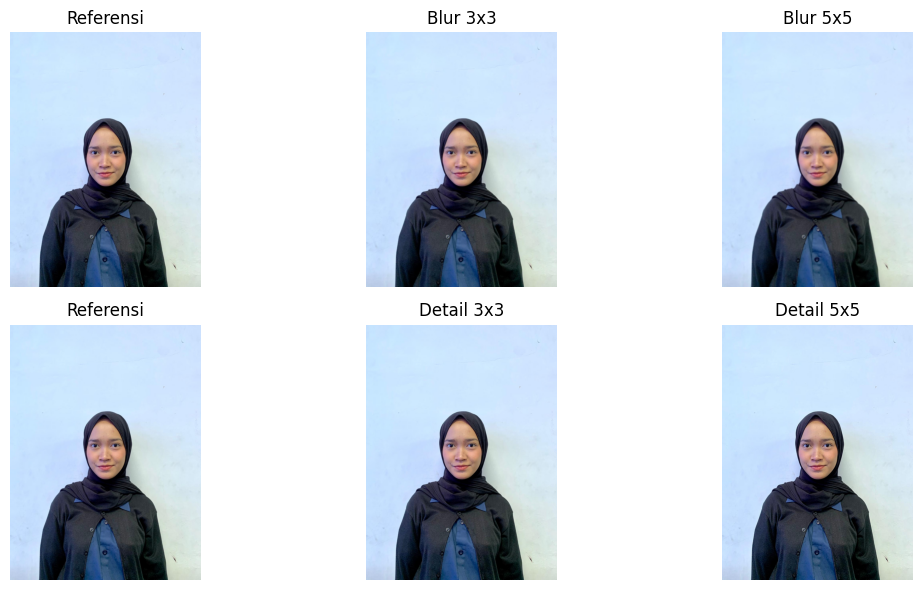

In [ ]:
def psnr(img_ref, img_test):
    ref = img_ref.astype(np.float32)
    tst = img_test.astype(np.float32)
    mse = np.mean((ref - tst) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

def unsharp_rgb(src, ksize=(3,3), amount=0.3):
    blur = cv2.blur(src, ksize)  # averaging blur (warna)
    out  = cv2.addWeighted(src, 1.0 + amount, blur, -amount, 0)
    return np.clip(out, 0, 255).astype(np.uint8)

# Ambil referensi
ref_path = next((p for p in IMAGE_PATHS if p.endswith('face2.jpg')), None)

ref_bgr = cv2.imread(ref_path, cv2.IMREAD_COLOR)
ref_rgb = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB)
print(f"Referensi (warna asli): {ref_path}")

# 1) Blur 3x3
blur3 = cv2.blur(ref_rgb, (3,3))

# 2) Blur 5x5
blur5 = cv2.blur(ref_rgb, (5,5))

# 3) Detail 3x3 (unsharp dengan blur 3x3, amount ringan)
detail3 = unsharp_rgb(ref_rgb, ksize=(3,3), amount=0.30)

# 4) Detail 5x5 (unsharp dengan blur 5x5, amount sedang)
detail5 = unsharp_rgb(ref_rgb, ksize=(5,5), amount=0.60)

# --- Hitung PSNR terhadap referensi (warna asli) ---
rows = [
    {"Skenario": "Blur 3x3",      "PSNR (dB)": round(psnr(ref_rgb, blur3), 3)},
    {"Skenario": "Blur 5x5",      "PSNR (dB)": round(psnr(ref_rgb, blur5), 3)},
    {"Skenario": "Detail 3x3",    "PSNR (dB)": round(psnr(ref_rgb, detail3), 3)},
    {"Skenario": "Detail 5x5",    "PSNR (dB)": round(psnr(ref_rgb, detail5), 3)},
]
df_psnr = pd.DataFrame(rows)
print(df_psnr)

# --- Visualisasi hasil ---
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(ref_rgb); plt.title('Referensi'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(blur3); plt.title('Blur 3x3'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(blur5); plt.title('Blur 5x5'); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(ref_rgb); plt.title('Referensi'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(detail3); plt.title('Detail 3x3'); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(detail5); plt.title('Detail 5x5'); plt.axis('off')
plt.tight_layout(); plt.show()

# Analisis Pra-Pemrosesan Citra Wajah untuk Pengenalan Wajah

1.  Urutan Proses Terbaik untuk Menghasilkan Wajah Paling Siap Recognition

Urutan proses terbaik dalam menghasilkan wajah yang paling siap untuk pengenalan adalah sebagai berikut:
Normalisasi pencahayaan untuk memastikan distribusi intensitas cahaya merata pada seluruh area wajah.
Konversi ke grayscale (jika diperlukan) untuk menyederhanakan data warna tanpa kehilangan informasi penting.

Penerapan unsharp masking dengan kernel 3×3 sebagai tahap penajaman detail wajah.

Metode ini terbukti memberikan hasil visual yang tajam dan alami tanpa menimbulkan noise atau distorsi yang berlebihan. Berdasarkan hasil pengujian, metode Detail 3×3 menghasilkan PSNR tertinggi (50,223 dB), yang menunjukkan citra tersebut paling mendekati kualitas citra asli dan paling sesuai untuk proses pengenalan wajah.

2. Perbandingan Nilai PSNR antara Citra Asli dan Hasil Pra-Pemrosesan

Nilai **PSNR** digunakan untuk mengukur tingkat kesamaan antara citra hasil pemrosesan dan citra aslinya. Berikut hasil perbandingannya:

| **Skenario** | **PSNR (dB)** |
|---------------|---------------|
| Blur 3×3      | 39.798        |
| Blur 5×5      | 35.312        |
| Detail 3×3    | 50.223        |
| Detail 5×5    | 40.077        |

Dari tabel tersebut terlihat bahwa **Detail 3×3** memiliki nilai PSNR tertinggi, artinya kualitasnya paling mendekati citra asli.  
Sementara itu, **Blur 5×5** memiliki PSNR terendah, yang berarti tingkat kehilangan detailnya paling besar akibat proses penghalusan yang terlalu kuat.Dengan demikian, peningkatan detail menggunakan *unsharp masking* memberikan hasil yang lebih baik dibandingkan metode *blur*,  karena mampu menonjolkan fitur wajah tanpa menurunkan kualitas keseluruhan.


3. Rekomendasi Metode Peningkatan Kualitas Wajah untuk Sistem Real-Time

Untuk sistem **pengenalan wajah real-time**, metode peningkatan kualitas yang direkomendasikan adalah **unsharp masking** dengan **kernel 3×3** dan **nilai penajaman (amount) sekitar 0,3**.  
- Keunggulan metode ini antara lain:  
  - **Proses komputasi ringan**, sehingga sangat cocok untuk sistem real-time.  
  - Hasil penajaman **halus dan tidak menimbulkan artefak** yang mengganggu tampilan citra.  
  - **Detail wajah** seperti mata, hidung, dan kontur tampak lebih jelas, membantu algoritma pengenalan wajah bekerja lebih akurat.  
- Sementara itu, **metode blur** sebaiknya hanya digunakan pada tahap **pra-pemrosesan** tertentu, misalnya untuk **mengurangi noise**, bukan untuk meningkatkan ketajaman citra wajah.

**KESIMPULAN**

Dari hasil praktikum yang telah dilakukan, dapat disimpulkan bahwa:

Teknik **unsharp masking kernel 3×3** merupakan metode paling efektif untuk meningkatkan kualitas citra wajah. Nilai **PSNR yang tinggi (50,223 dB)** menunjukkan hasil citra yang tajam namun tetap alami. Metode ini sangat cocok digunakan pada **sistem pengenalan wajah real-time** karena memberikan hasil optimal tanpa beban pemrosesan yang berat. Dengan demikian, penggunaan **unsharp masking 3×3** dapat direkomendasikan sebagai tahapan standar dalam proses **pra-pemrosesan citra wajah** sebelum dilakukan pengenalan otomatis.